In [ ]:
#Phase -1 Data Understanding and EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#Loading the dataset
df = pd.read_csv('/content/data.csv')
df.rename(columns={'default payment next month':'default'},inplace=True)

In [ ]:
print(df.head(),)
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())

   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   
3   4      50000    2          2         1   37      0      0      0      0   
4   5      50000    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...          0          0          0         0       689         0   
1  ...       3272       3455       3261         0      1000      1000   
2  ...      14331      14948      15549      1518      1500      1000   
3  ...      28314      28959      29547      2000      2019      1200   
4  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default  
0         0         0         0        1  


In [ ]:
 #print(df['default'].value_counts())
 print(df['default'].value_counts(normalize=True)*100)

default
0    77.88
1    22.12
Name: proportion, dtype: float64


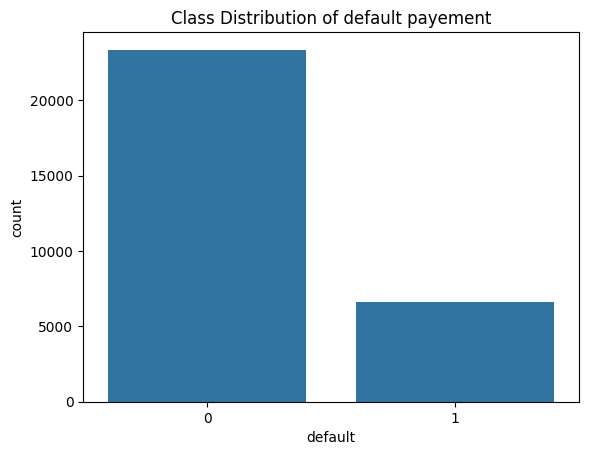

In [ ]:
#visualization
#class distribution
sns.countplot(x='default',data=df)
plt.title('Class Distribution of default payement')
plt.show()

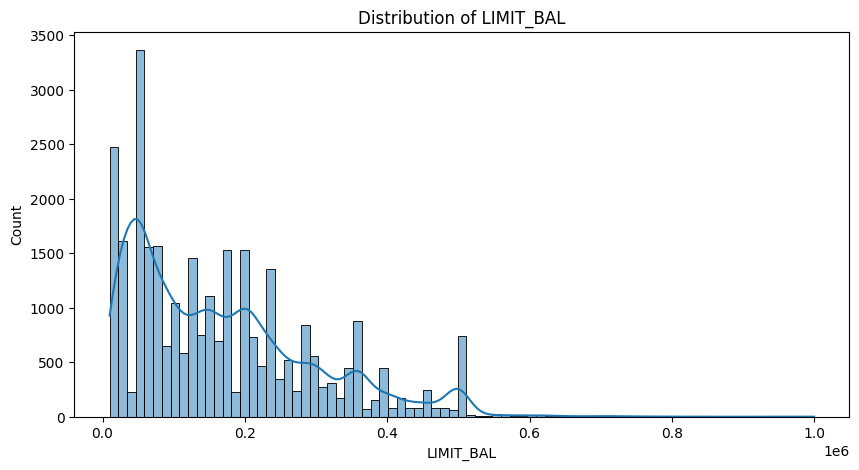

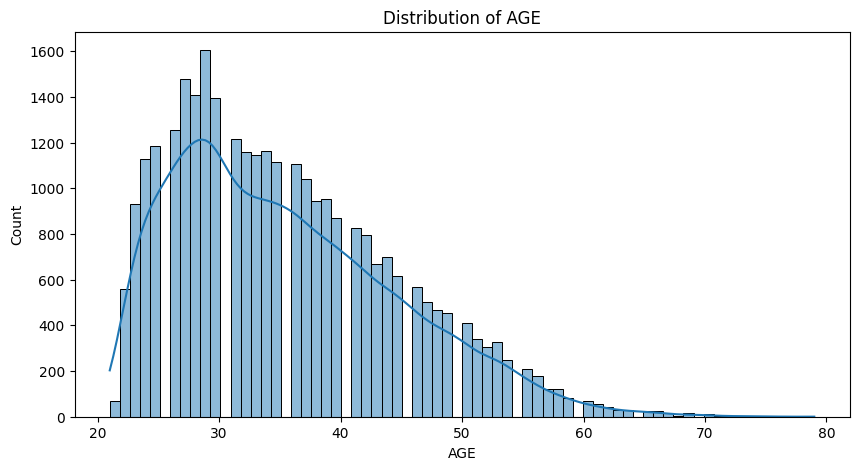

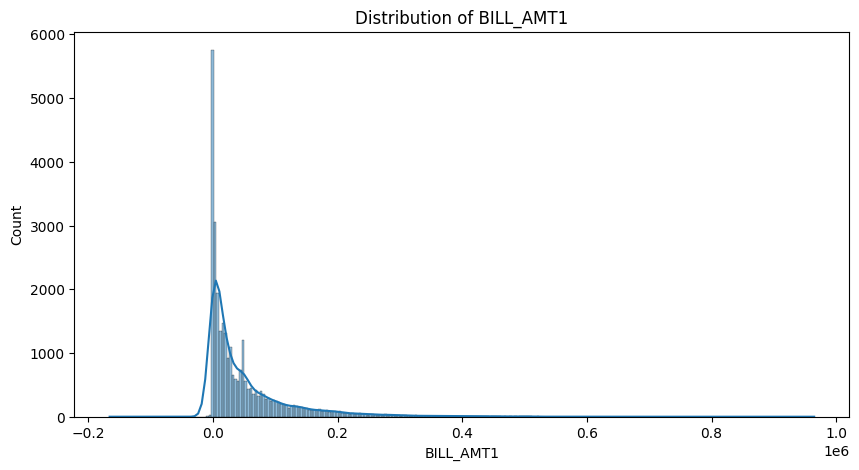

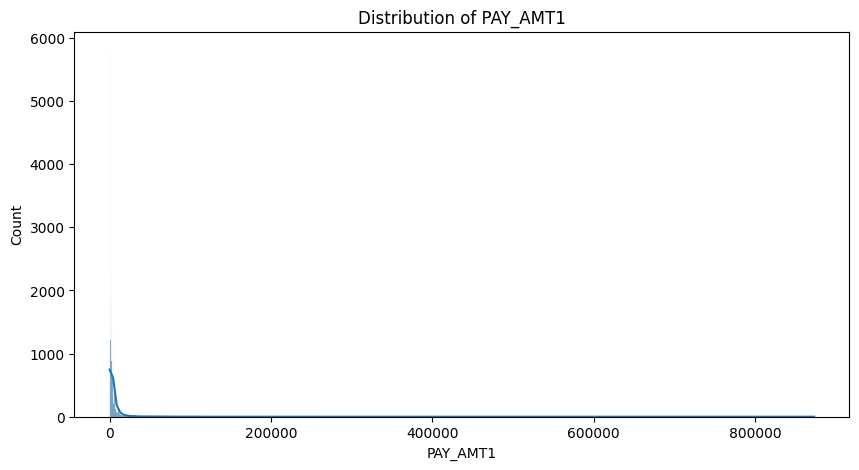

In [ ]:
#feature Distribution
features=['LIMIT_BAL','AGE','BILL_AMT1','PAY_AMT1']
for feature in features:
  plt.figure(figsize=(10,5))
  sns.histplot(df[feature],kde=True)
  plt.title(f'Distribution of {feature}')
  plt.show()


In [ ]:
# Phase- 2 Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# splitting the data ( with stratification)
x=df.drop('default',axis=1)
y=df['default']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
scalar = StandardScaler()
x_train_scaled=scalar.fit_transform(x_train)
x_test_scaled=scalar.transform(x_test)

In [ ]:
#Phase3+model building and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,precision_score,recall_score,f1_score, roc_auc_score

In [ ]:
models ={
    "logistic regression(l2)":LogisticRegression(class_weight='balanced',
                                                 penalty='l2',
                                                 solver='lbfgs',
                                                 max_iter=8000,
                                                 random_state=42),
    "knn":KNeighborsClassifier(n_neighbors=5,
                               weights='uniform',
                               n_jobs=-1),
    "decision tree":DecisionTreeClassifier(class_weight='balanced',
                                           random_state=42),
    "random forest":RandomForestClassifier(class_weight='balanced',
                                           n_estimators=100,
                                           random_state=42,
                                           n_jobs=-1),
    "svm":SVC(kernel='rbf',
              class_weight='balanced',
              probability=True,
              random_state=42),
    "naive bayes":GaussianNB(),
    "gradient boosting":GradientBoostingClassifier(n_estimators=100,
                                                   random_state=42),
    "xgboost":XGBClassifier(n_estimators=100,
                            random_state=42,
                            eval_metric='logloss',
                            tree_method='hist')

}

In [ ]:
results =[]
for name,model in models.items():
  if name in ['knn','svm','logistic regression(l2)']:
    model.fit(x_train_scaled,y_train)
    y_pred=model.predict(x_test_scaled)
  else:
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)

  cmm=confusion_matrix(y_test,y_pred)
  acc=accuracy_score(y_test,y_pred)
  print("\nModel:",name)
  print("Confusion Matrix:")
  print(cmm)

  results.append({"model":name,
                  "accuracy":accuracy_score(y_test,y_pred),
                  "precision":precision_score(y_test,y_pred),
                  "recall":recall_score(y_test,y_pred),
                  "f1 score":f1_score(y_test,y_pred),
                  "roc auc":roc_auc_score(y_test,y_pred)})
  results_df=pd.DataFrame(results)
  print("\n-----Comparison of Models-----\n")
  print(results_df)



Model: logistic regression(l2)
Confusion Matrix:
[[3263 1410]
 [ 502  825]]

-----Comparison of Models-----

                     model  accuracy  precision    recall  f1 score   roc auc
0  logistic regression(l2)  0.681333   0.369128  0.621703  0.463223  0.659985

Model: knn
Confusion Matrix:
[[4302  371]
 [ 868  459]]

-----Comparison of Models-----

                     model  accuracy  precision    recall  f1 score   roc auc
0  logistic regression(l2)  0.681333   0.369128  0.621703  0.463223  0.659985
1                      knn  0.793500   0.553012  0.345893  0.425591  0.633250

Model: decision tree
Confusion Matrix:
[[3893  780]
 [ 801  526]]

-----Comparison of Models-----

                     model  accuracy  precision    recall  f1 score   roc auc
0  logistic regression(l2)  0.681333   0.369128  0.621703  0.463223  0.659985
1                      knn  0.793500   0.553012  0.345893  0.425591  0.633250
2            decision tree  0.736500   0.402757  0.396383  0.399544  0.61473

In [ ]:
#Phase 4 - Hyperparameter tuning
#tuning random forest
from sklearn.model_selection import StratifiedKFold,RandomizedSearchCV,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
from xgboost import XGBClassifier

In [ ]:
import numpy as np
akf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
#baseline random forest
rf_base=RandomForestClassifier(class_weight='balanced',
                               random_state=42)
rf_base.fit(x_train,y_train)
y_pred_base=rf_base.predict(x_test)
y_prob_base=rf_base.predict_proba(x_test)[:,1]
"""print("\nBaseline Random Forest Results:")
print("Accuracy:",accuracy_score(y_test,y_pred_base))
print("Precision:",precision_score(y_test,y_pred_base))
print("Recall:",recall_score(y_test,y_pred_base))
print("F1 Score:",f1_score(y_test,y_pred_base))
print("ROC AUC:",roc_auc_score(y_test,y_prob_base))"""


'print("\nBaseline Random Forest Results:")\nprint("Accuracy:",accuracy_score(y_test,y_pred_base)) \nprint("Precision:",precision_score(y_test,y_pred_base))\nprint("Recall:",recall_score(y_test,y_pred_base))\nprint("F1 Score:",f1_score(y_test,y_pred_base))\nprint("ROC AUC:",roc_auc_score(y_test,y_prob_base))'

In [ ]:
#randomized hyper parameter tuning for random forest
rf_params_grids={
    'n_estimators':[100,200],
    'max_depth':[None,10],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2],
    'class_weight':['balanced',None]
}
rf_grid=RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_distributions=rf_params_grids,
                           cv=akf,
                           n_jobs=-1,
                           verbose=2,
                           scoring='f1')
rf_grid.fit(x_train,y_train)
print("best parametes for random forest",rf_grid.best_params_)
best_rf=rf_grid.best_estimator_

y_pred_tuned=best_rf.predict(x_test)
y_prob_tuned = best_rf.predict_proba(x_test)[:,1]

"""print("\nTuned Random Forest Results:")
print("Accuracy:",accuracy_score(y_test,y_pred_tuned))
print("Precision:",precision_score(y_test,y_pred_tuned))
print("Recall:",recall_score(y_test,y_pred_tuned))
print("F1 Score:",f1_score(y_test,y_pred_tuned))
print("ROC AUC:",roc_auc_score(y_test,y_prob_tuned))"""

Fitting 5 folds for each of 10 candidates, totalling 50 fits
best parametes for random forest {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'class_weight': 'balanced'}


'print("\nTuned Random Forest Results:")\nprint("Accuracy:",accuracy_score(y_test,y_pred_tuned))\nprint("Precision:",precision_score(y_test,y_pred_tuned))\nprint("Recall:",recall_score(y_test,y_pred_tuned))\nprint("F1 Score:",f1_score(y_test,y_pred_tuned))\nprint("ROC AUC:",roc_auc_score(y_test,y_prob_tuned))'

In [ ]:
#xgboost baseline
xgb_base=XGBClassifier(n_estimators=100,
                       random_state=42)
xgb_base.fit(x_train,y_train)
y_pred_base=xgb_base.predict(x_test)
y_prob_xgb=xgb_base.predict_proba(x_test)[:,1]

"""print("\nXGBOOST Baseline Results:")
print("Accuracy:",accuracy_score(y_test,y_pred_xgb))
print("Precision:",precision_score(y_test,y_pred_xgb))
print("Recall:",recall_score(y_test,y_pred_xgb))
print("F1 Score:",f1_score(y_test,y_pred_xgb))
print("ROC AUC:",roc_auc_score(y_test,y_prob_xgb))"""
#randomized hyperparameter tuning for xgboost
xgb_params_grids={
    'n_estimators':[100,300],
    'max_depth':[3,8],
    'learning_rate':[0.01,0.1],
    'subsample':[0.8,1],
    'colsample_bytree':[0.8,1],
    "scale_pos_weight":[1,5]
}

xgb_grid=RandomizedSearchCV(estimator=XGBClassifier(random_state=42,
                           eval_metric='logloss'),
                           param_distributions=xgb_params_grids,
                           cv=akf,
                           n_jobs=-1,
                           verbose=2,
                           scoring='f1')
xgb_grid.fit(x_train,y_train)
print("best parameters for XGBoost:",xgb_grid.best_params_)
best_xgb=xgb_grid.best_estimator_

y_pred_xgb_tuned=best_xgb.predict(x_test)
y_prob_xgb_tuned=best_xgb.predict_proba(x_test)[:,1]


"""print("\nTuned XGBOOST Results:")
print("Accuracy:",accuracy_score(y_test,y_pred_xgb_tuned))
print("Precision:",precision_score(y_test,y_pred_xgb_tuned))
print("Recall:",recall_score(y_test,y_pred_xgb_tuned))
print("F1 Score:",f1_score(y_test,y_pred_xgb_tuned))
print("ROC AUC:",roc_auc_score(y_test,y_prob_xgb_tuned))"""

Fitting 5 folds for each of 10 candidates, totalling 50 fits
best parameters for XGBoost: {'subsample': 1, 'scale_pos_weight': 5, 'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


'print("\nTuned XGBOOST Results:")\nprint("Accuracy:",accuracy_score(y_test,y_pred_xgb_tuned))\nprint("Precision:",precision_score(y_test,y_pred_xgb_tuned))\nprint("Recall:",recall_score(y_test,y_pred_xgb_tuned))\nprint("F1 Score:",f1_score(y_test,y_pred_xgb_tuned))\nprint("ROC AUC:",roc_auc_score(y_test,y_prob_xgb_tuned))'

In [ ]:
#evaluation of tuned models and baseline models
def evaluate(name,y_true,y_pred,y_prob):
  return {
      "Model":name,
      "Accuracy":accuracy_score(y_true,y_pred),
      "Precision":precision_score(y_true,y_pred),
      "Recall":recall_score(y_true,y_pred),
      "F1 Score":f1_score(y_true,y_pred),
      "ROC AUC":roc_auc_score(y_true,y_prob)
  }
  results=[]
  results.append(evaluate("RF Baseline",y_test,y_pred_base,y_prob_base))
  results.append(evaluate("RF Tuned",y_test,y_pred_tuned,y_prob_tuned))
  results.append(evaluate("XGB Baseline",y_test,y_pred_xgb,y_prob_xgb))
  results.append(evaluate("XGB Tuned",y_test,y_pred_xgb_tuned,y_prob_xgb_tuned))
  import pandas as pd
  comparison_df=pd.DataFrame(results)
  comparison_df=comparison_dfsort_values(by="F1Score",ascending=False)


  print("\n====Phase 4Final Comparison of Models====")
  print(comparison_df)
